# Statistiques d'annotation — comparaison multi-corpus (article)

Ce notebook parcourt automatiquement les dossiers `annotation/outputs/run_*`
qui contiennent un fichier `*__annotated.xlsx` (résultats passe 1 v13).

**Tableau** : nombre de récits, unités factuelles, % A0 / A1 / B / C.

**Graphique** : distributions des classes par corpus (comparaison visuelle).


In [1]:
import os
import sys
from pathlib import Path


def _notebook_find_text_root(start: Path) -> Path:
    here = start.resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "safer_core" / "paths.py").is_file():
            return candidate
        nested = candidate / "text"
        if (nested / "safer_core" / "paths.py").is_file():
            return nested
    raise FileNotFoundError(
        "Racine text/ introuvable (safer_core/paths.py). "
        "Ouvrez Jupyter depuis le dossier text/ ou SAFER/."
    )


TEXT_ROOT = _notebook_find_text_root(Path.cwd())
if str(TEXT_ROOT) not in sys.path:
    sys.path.insert(0, str(TEXT_ROOT))
os.chdir(TEXT_ROOT)


In [2]:
# --- Paramètres ---
from pathlib import Path

OUTPUTS_DIR = TEXT_ROOT / "annotation" / "outputs"
ONLY_RUN_IDS = None  # ex. ["run_all_btp", "run_all_metallurgie"] ou None = auto

print("OUTPUTS_DIR =", OUTPUTS_DIR)


OUTPUTS_DIR = C:\Users\aho\Documents\analysis factor project\SAFER\text\annotation\outputs


In [3]:
# --- Découverte des runs annotées ---
from IPython.display import display

from annotation.article_stats import (
    build_label_distribution_long,
    build_summary_table,
    discover_annotation_runs,
)

all_runs = discover_annotation_runs(OUTPUTS_DIR)
if ONLY_RUN_IDS:
    allowed = set(ONLY_RUN_IDS)
    runs = [run for run in all_runs if run["run_id"] in allowed]
else:
    runs = all_runs

if not runs:
    raise FileNotFoundError(
        f"Aucune run avec *__annotated.xlsx dans {OUTPUTS_DIR}.\n"
        "Lancez d'abord ingest sur au moins un corpus."
    )

print(f"{len(runs)} corpus trouvé(s) :")
for run in runs:
    print(f"  - {run['corpus']} ({run['run_id']})")
    print(f"    → {run['annotated_path'].name}")


3 corpus trouvé(s) :
  - BTP (run_all_btp)
    → gpt-5.4-nano__v13_two_pass_ambiguity_context__pass1__annotated.xlsx
  - Caoutchouc-chimie-plastiques (run_all_caou_chimie_plas)
    → gpt-5.4-nano__v13_two_pass_ambiguity_context__pass1__annotated.xlsx
  - Métallurgie (run_all_metallurgie)
    → gpt-5.4-nano__v13_two_pass_ambiguity_context__pass1__annotated.xlsx


In [4]:
# --- Tableau récapitulatif (article) ---
summary_table = build_summary_table(runs)

display_cols = [
    "corpus",
    "n_recits",
    "n_units",
    "n_annotated",
    "pct_A0",
    "pct_A1",
    "pct_B",
    "pct_C",
]
article_table = summary_table[display_cols].copy()
article_table = article_table.rename(
    columns={
        "corpus": "Corpus",
        "n_recits": "Nb récits",
        "n_units": "Nb unités factuelles",
        "n_annotated": "Nb annotées (pred_ok)",
        "pct_A0": "% A0",
        "pct_A1": "% A1",
        "pct_B": "% B",
        "pct_C": "% C",
    }
)

print("Tableau synthèse (pour article)")
display(article_table)

summary_table


Tableau synthèse (pour article)


,Corpus,Nb récits,Nb unités factuelles,Nb annotées (pred_ok),% A0,% A1,% B,% C
0,BTP,6040,42309,42244,53.02,12.10,17.71,17.17
1,Caoutchouc-chimie-plastiques,838,6178,6157,54.98,12.77,13.95,18.30
2,Métallurgie,3212,22487,22456,54.30,12.07,15.49,18.13


,corpus,n_recits,n_units,n_annotated,n_missing_or_failed,pct_A0,pct_A1,pct_B,pct_C,n_A0,n_A1,n_B,n_C
0,BTP,6040,42309,42244,65,53.02,12.10,17.71,17.17,22398,5112,7480,7254
1,Caoutchouc-chimie-plastiques,838,6178,6157,21,54.98,12.77,13.95,18.30,3385,786,859,1127
2,Métallurgie,3212,22487,22456,31,54.30,12.07,15.49,18.13,12194,2711,3479,4072


In [5]:
# --- Distribution des classes (données longues) ---
dist_long = build_label_distribution_long(runs)
dist_long


,corpus,run_id,label,n_units,pct
0,BTP,run_all_btp,A0,22398,53.02
1,BTP,run_all_btp,A1,5112,12.10
2,BTP,run_all_btp,B,7480,17.71
3,BTP,run_all_btp,C,7254,17.17
4,Caoutchouc-chimie-plastiques,run_all_caou_chimie_plas,A0,3385,54.98
5,Caoutchouc-chimie-plastiques,run_all_caou_chimie_plas,A1,786,12.77
6,Caoutchouc-chimie-plastiques,run_all_caou_chimie_plas,B,859,13.95
7,Caoutchouc-chimie-plastiques,run_all_caou_chimie_plas,C,1127,18.30
8,Métallurgie,run_all_metallurgie,A0,12194,54.30
9,Métallurgie,run_all_metallurgie,A1,2711,12.07


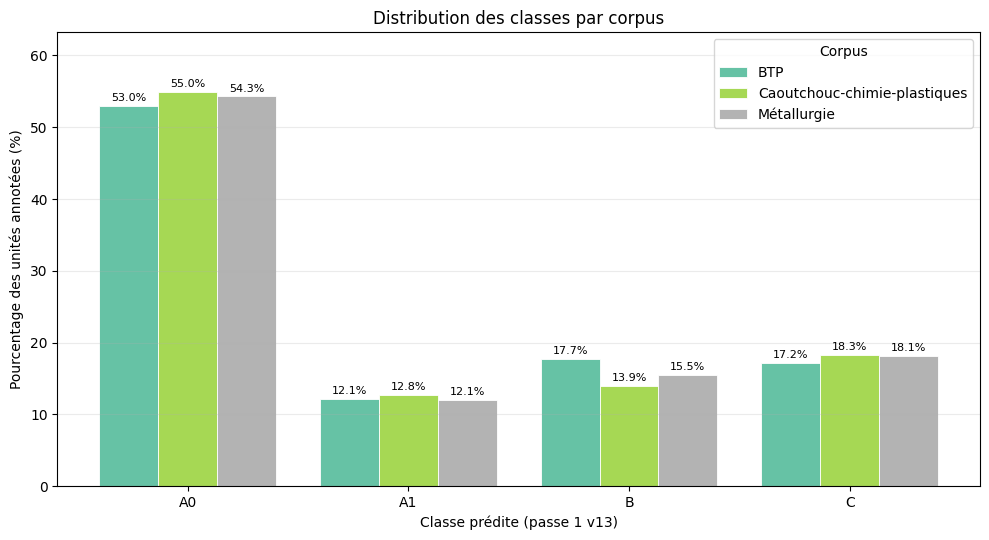

In [6]:
# --- Graphique : % par classe, comparaison des corpus ---
import matplotlib.pyplot as plt
import numpy as np

if dist_long.empty:
    raise ValueError("Aucune distribution à tracer.")

corpora = list(dist_long["corpus"].unique())
labels = ["A0", "A1", "B", "C"]
x = np.arange(len(labels))
width = 0.8 / max(len(corpora), 1)

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = plt.cm.Set2(np.linspace(0, 1, len(corpora)))

for i, corpus in enumerate(corpora):
    subset = dist_long[dist_long["corpus"] == corpus].set_index("label").reindex(labels)
    offset = (i - (len(corpora) - 1) / 2) * width
    bars = ax.bar(
        x + offset,
        subset["pct"].values,
        width=width,
        label=corpus,
        color=colors[i],
        edgecolor="white",
        linewidth=0.6,
    )
    for bar, pct in zip(bars, subset["pct"].values):
        if pct >= 3:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.4,
                f"{pct:.1f}%",
                ha="center",
                va="bottom",
                fontsize=8,
            )

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Pourcentage des unités annotées (%)")
ax.set_xlabel("Classe prédite (passe 1 v13)")
ax.set_title("Distribution des classes par corpus")
ax.legend(title="Corpus", loc="upper right")
ax.set_ylim(0, max(dist_long["pct"].max() * 1.15, 10))
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


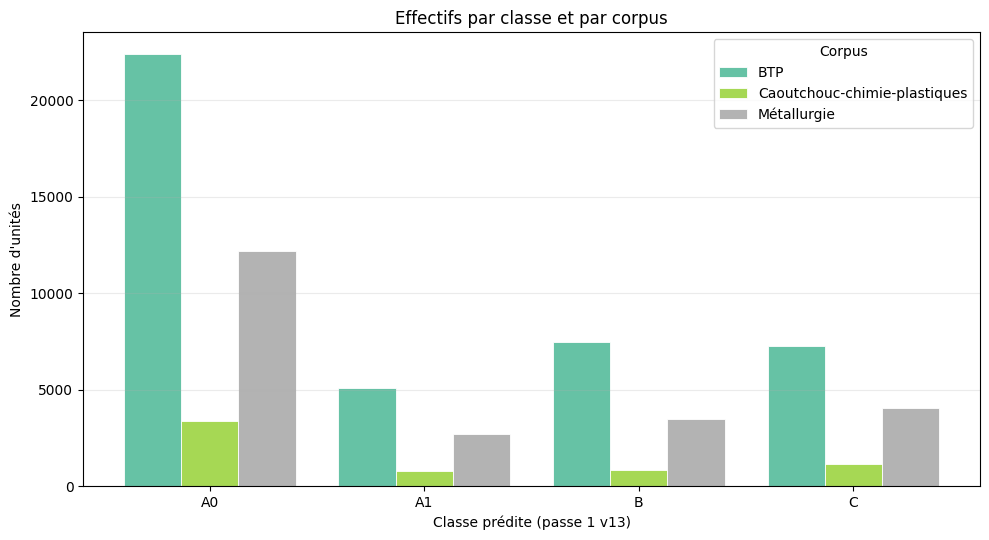

In [7]:
# --- Graphique alternatif : effectifs absolus ---
fig, ax = plt.subplots(figsize=(10, 5.5))

for i, corpus in enumerate(corpora):
    subset = dist_long[dist_long["corpus"] == corpus].set_index("label").reindex(labels)
    offset = (i - (len(corpora) - 1) / 2) * width
    ax.bar(
        x + offset,
        subset["n_units"].values,
        width=width,
        label=corpus,
        color=colors[i],
        edgecolor="white",
        linewidth=0.6,
    )

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Nombre d'unités")
ax.set_xlabel("Classe prédite (passe 1 v13)")
ax.set_title("Effectifs par classe et par corpus")
ax.legend(title="Corpus", loc="upper right")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


In [8]:
# --- Export optionnel du tableau (CSV / XLSX) ---
export_dir = OUTPUTS_DIR / "_article_exports"
export_dir.mkdir(parents=True, exist_ok=True)

article_xlsx = export_dir / "annotation_corpus_summary.xlsx"
article_csv = export_dir / "annotation_corpus_summary.csv"

article_table.to_excel(article_xlsx, index=False)
article_table.to_csv(article_csv, index=False, encoding="utf-8-sig")

print("Exporté :")
print(" ", article_xlsx)
print(" ", article_csv)


Exporté :
  C:\Users\aho\Documents\analysis factor project\SAFER\text\annotation\outputs\_article_exports\annotation_corpus_summary.xlsx
  C:\Users\aho\Documents\analysis factor project\SAFER\text\annotation\outputs\_article_exports\annotation_corpus_summary.csv
